正在生成时空序列数据...
开始训练 LST-GCN 模型 (使用 GPU)...
Epoch [10/100], Train Loss: 0.0306, Test Loss: 0.0204
Epoch [20/100], Train Loss: 0.0104, Test Loss: 0.0099
Epoch [30/100], Train Loss: 0.0052, Test Loss: 0.0050
Epoch [40/100], Train Loss: 0.0041, Test Loss: 0.0041
Epoch [50/100], Train Loss: 0.0035, Test Loss: 0.0035
Epoch [60/100], Train Loss: 0.0032, Test Loss: 0.0033
Epoch [70/100], Train Loss: 0.0031, Test Loss: 0.0031
Epoch [80/100], Train Loss: 0.0029, Test Loss: 0.0030
Epoch [90/100], Train Loss: 0.0028, Test Loss: 0.0028
Epoch [100/100], Train Loss: 0.0027, Test Loss: 0.0027


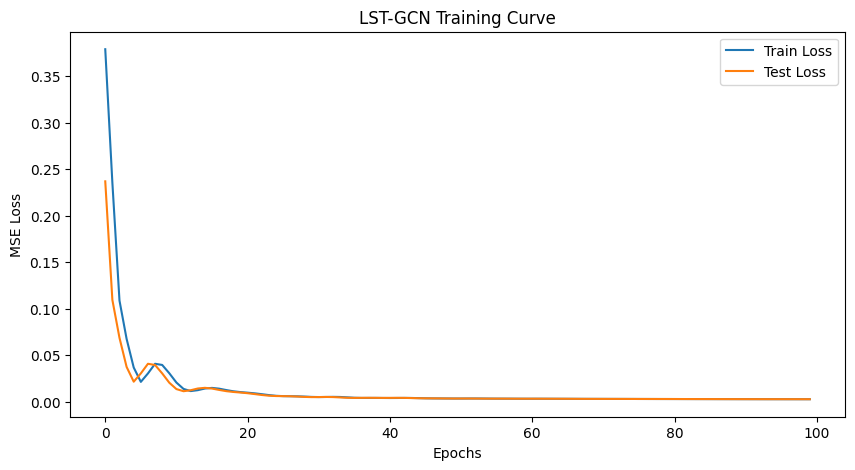

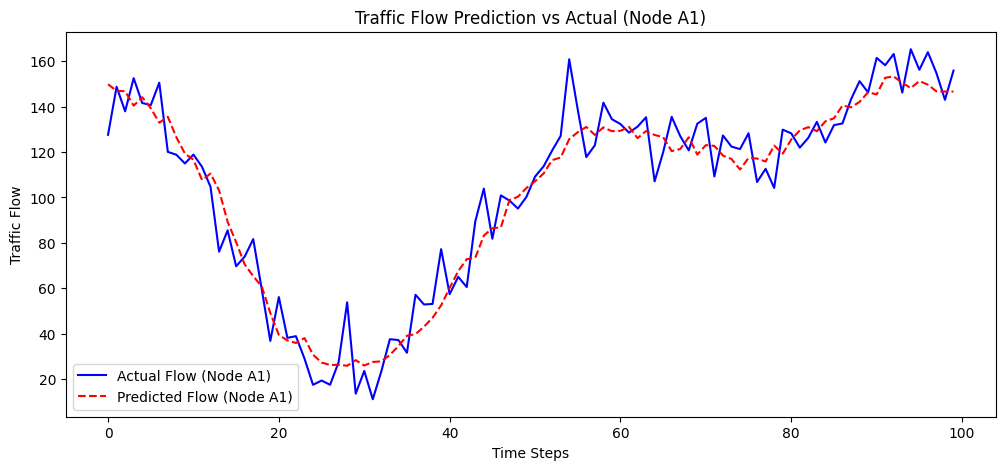

✅ 模型训练完成！权重已保存为 'lst_gcn_weights.pth'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==========================================
# 1. 数据准备 (模拟我们在 MySQL 中生成的数据)
# ==========================================
print("正在生成时空序列数据...")
num_nodes = 7
seq_length = 2000 # 模拟 2000 个时间步
# 节点名称对应: A1, B2, C3, D4, E5, F6, G7
data = np.zeros((seq_length, num_nodes))

for t in range(seq_length):
    hour = (t % 96) / 4.0 # 假设每天 96 个时间步 (15分钟一次)
    # 模拟早晚高峰的基准波形
    base_wave = 100 + 50 * math.sin(math.pi * (hour - 6) / 12) + 30 * math.sin(math.pi * (hour - 14) / 6)
    for n in range(num_nodes):
        # 不同节点加上不同的随机噪声和相位偏移
        data[t, n] = max(10, base_wave + np.random.normal(0, 10) + n * 5)

# 归一化数据 (深度学习必备步骤)
max_val = np.max(data)
data_norm = data / max_val

# ==========================================
# 2. 构建图的邻接矩阵 (Adjacency Matrix)
# ==========================================
# 假设 7 个路口的连接关系 (1 表示相连，0 表示不相连)
A = np.array([
    [1, 1, 1, 0, 0, 0, 0], # A1 连接 B2, C3
    [1, 1, 0, 1, 0, 0, 0], # B2 连接 A1, D4
    [1, 0, 1, 0, 1, 0, 0], # C3 连接 A1, E5
    [0, 1, 0, 1, 0, 1, 0], # D4 连接 B2, F6
    [0, 0, 1, 0, 1, 0, 1], # E5 连接 C3, G7
    [0, 0, 0, 1, 0, 1, 0], # F6 连接 D4
    [0, 0, 0, 0, 1, 0, 1], # G7 连接 E5
])

# 计算 GCN 所需的拉普拉斯矩阵: D^(-1/2) * A * D^(-1/2)
D = np.diag(np.sum(A, axis=1))
D_inv_sqrt = np.linalg.inv(np.sqrt(D))
A_hat = np.dot(np.dot(D_inv_sqrt, A), D_inv_sqrt)
A_hat_tensor = torch.FloatTensor(A_hat).cuda() # 移至 GPU

# ==========================================
# 3. 构建 LST-GCN 模型
# ==========================================
class GCNLayer(nn.Module):
    """图卷积层：提取空间特征 (路口之间的相互影响)"""
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        # X * W
        support = torch.matmul(x, self.weight)
        # A_hat * (X * W)
        output = torch.matmul(adj, support)
        return torch.relu(output)

class LSTGCN(nn.Module):
    """LST-GCN 核心模型"""
    def __init__(self, num_nodes, in_dim, hidden_dim, out_dim):
        super(LSTGCN, self).__init__()
        self.gcn = GCNLayer(in_dim, hidden_dim)
        # LSTM 提取时间特征 (历史流量的变化趋势)
        self.lstm = nn.LSTM(num_nodes * hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_nodes * out_dim)
        self.num_nodes = num_nodes

    def forward(self, x, adj):
        batch_size, seq_len, num_nodes = x.shape
        # 1. 空间特征提取 (GCN)
        gcn_out = torch.zeros(batch_size, seq_len, num_nodes, self.gcn.weight.shape[1]).cuda()
        for t in range(seq_len):
            gcn_out[:, t, :, :] = self.gcn(x[:, t, :].unsqueeze(-1), adj)

        # 2. 时间特征提取 (LSTM)
        lstm_in = gcn_out.view(batch_size, seq_len, -1)
        lstm_out, _ = self.lstm(lstm_in)

        # 3. 预测未来流量
        # 取 LSTM 最后一个时间步的输出进行预测
        out = self.fc(lstm_out[:, -1, :])
        return out.view(batch_size, num_nodes)

# ==========================================
# 4. 制作训练集 (滑动窗口机制)
# ==========================================
def create_dataset(data, window_size, horizon):
    X, Y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i : i + window_size])
        Y.append(data[i + window_size + horizon - 1])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(Y))

window_size = 12 # 用过去 12 个时间步 (3小时)
horizon = 1      # 预测未来 1 个时间步 (15分钟)

X, Y = create_dataset(data_norm, window_size, horizon)
# 划分训练集和测试集 (80% 训练, 20% 测试)
split = int(0.8 * len(X))
X_train, Y_train = X[:split].cuda(), Y[:split].cuda()
X_test, Y_test = X[split:].cuda(), Y[split:].cuda()

# ==========================================
# 5. 开始训练模型
# ==========================================
model = LSTGCN(num_nodes=7, in_dim=1, hidden_dim=64, out_dim=1).cuda()
criterion = nn.MSELoss() # 均方误差损失
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 100
train_losses, test_losses = [], []

print("开始训练 LST-GCN 模型 (使用 GPU)...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # 前向传播
    outputs = model(X_train, A_hat_tensor)
    loss = criterion(outputs, Y_train)

    # 反向传播与优化
    loss.backward()
    optimizer.step()

    # 测试集验证
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test, A_hat_tensor)
        test_loss = criterion(test_outputs, Y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# ==========================================
# 6. 结果可视化与模型保存
# ==========================================
# 绘制 Loss 曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('LST-GCN Training Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# 绘制节点 A1 的预测对比图 (取测试集前 100 个点)
model.eval()
with torch.no_grad():
    preds = model(X_test[:100], A_hat_tensor).cpu().numpy() * max_val
    actuals = Y_test[:100].cpu().numpy() * max_val

plt.figure(figsize=(12, 5))
plt.plot(actuals[:, 0], label='Actual Flow (Node A1)', color='blue')
plt.plot(preds[:, 0], label='Predicted Flow (Node A1)', color='red', linestyle='dashed')
plt.title('Traffic Flow Prediction vs Actual (Node A1)')
plt.xlabel('Time Steps')
plt.ylabel('Traffic Flow')
plt.legend()
plt.show()

# 保存模型权重
torch.save(model.state_dict(), 'lst_gcn_weights.pth')
print("✅ 模型训练完成！权重已保存为 'lst_gcn_weights.pth'")